In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

# Configuración visual
sns.set_theme(style="whitegrid")

# 1. Extracción de datos oceanográficos en tiempo real (Open-Meteo Marine API)
# Coordenadas de Palomino, La Guajira
url = "https://marine-api.open-meteo.com/v1/marine?latitude=11.24&longitude=-73.56&hourly=wave_height,ocean_current_velocity&timezone=America%2FBogota"

response = requests.get(url)
if response.status_code == 200:
    data = response.json()
    
    # Procesamiento del JSON a un DataFrame de Pandas
    df_ocean = pd.DataFrame({
        'Fecha_Hora': pd.to_datetime(data['hourly']['time']),
        'Altura_Ola_m': data['hourly']['wave_height'],
        'Velocidad_Corriente_kmh': data['hourly']['ocean_current_velocity']
    })
    
    # Limpiamos valores nulos si existen
    df_ocean.dropna(inplace=True)
    print("Datos oceanográficos obtenidos exitosamente.")
else:
    print("Error al conectar con la API.")

Datos oceanográficos obtenidos exitosamente.


In [4]:
# 2. Generación de dataset de erosión histórica (Simulado para el PoC)
# Asumimos un periodo de 10 años (2014 - 2024)
años = np.arange(2014, 2025)

# Simulamos una pérdida de costa en metros (tendencia al alza por cambio climático)
# Tasa base de pérdida + factor aleatorio + factor exponencial leve por cambio climático
np.random.seed(42)
tasa_base = 1.5 # metros por año
impacto_climatico = np.exp((años - 2014) * 0.1) 
perdida_anual = tasa_base + (impacto_climatico * 0.8) + np.random.normal(0, 0.5, len(años))
perdida_acumulada = np.cumsum(perdida_anual)

df_erosion = pd.DataFrame({
    'Año': años,
    'Perdida_Anual_m': perdida_anual,
    'Perdida_Acumulada_m': perdida_acumulada
})

print(df_erosion.tail())

     Año  Perdida_Anual_m  Perdida_Acumulada_m
6   2020         3.747301            20.031323
7   2021         3.494720            23.526043
8   2022         3.045696            26.571738
9   2023         3.738963            30.310701
10  2024         3.442917            33.753617


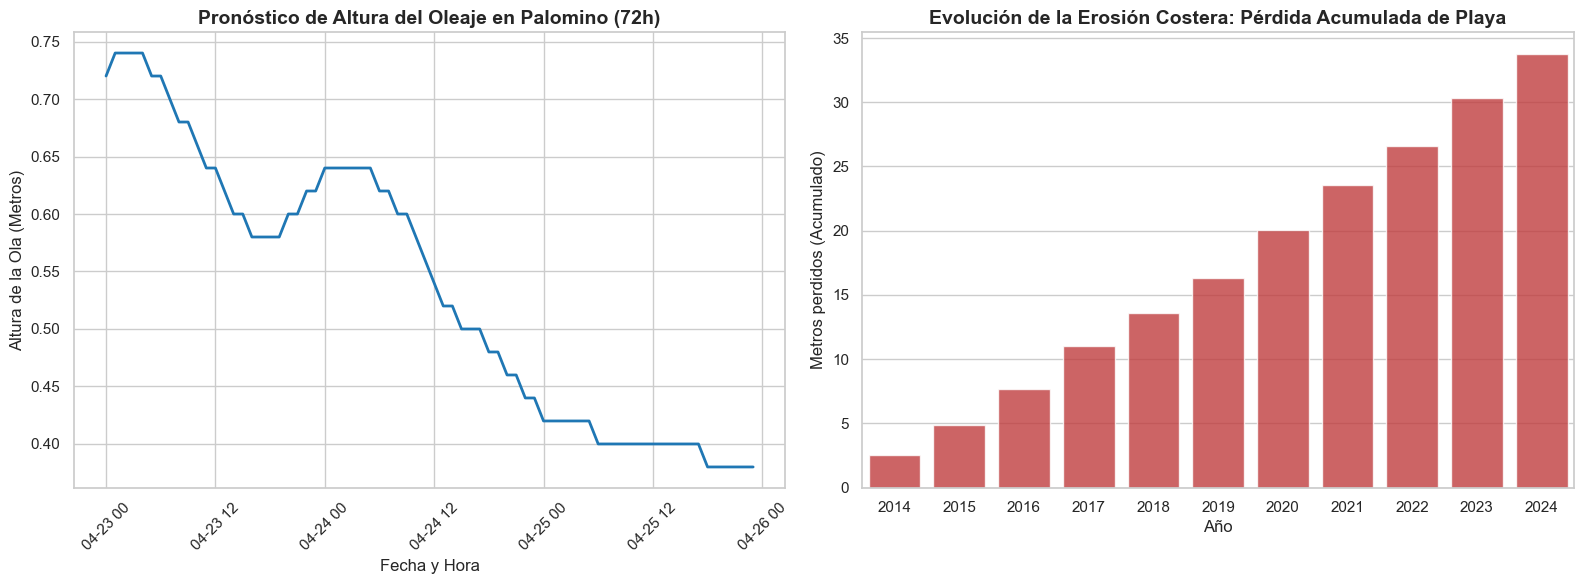

In [5]:
# 3. Visualización de los datos

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Pronóstico de Altura de Olas (Próximos días)
# Tomamos solo las primeras 72 horas para claridad
sns.lineplot(x='Fecha_Hora', y='Altura_Ola_m', data=df_ocean.head(72), ax=ax[0], color='#1f77b4', linewidth=2)
ax[0].set_title('Pronóstico de Altura del Oleaje en Palomino (72h)', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Fecha y Hora')
ax[0].set_ylabel('Altura de la Ola (Metros)')
ax[0].tick_params(axis='x', rotation=45)

# Gráfico 2: Evolución de la Erosión Costera
sns.barplot(x='Año', y='Perdida_Acumulada_m', data=df_erosion, ax=ax[1], color='#d62728', alpha=0.8)
ax[1].set_title('Evolución de la Erosión Costera: Pérdida Acumulada de Playa', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Año')
ax[1].set_ylabel('Metros perdidos (Acumulado)')

plt.tight_layout()
plt.show()

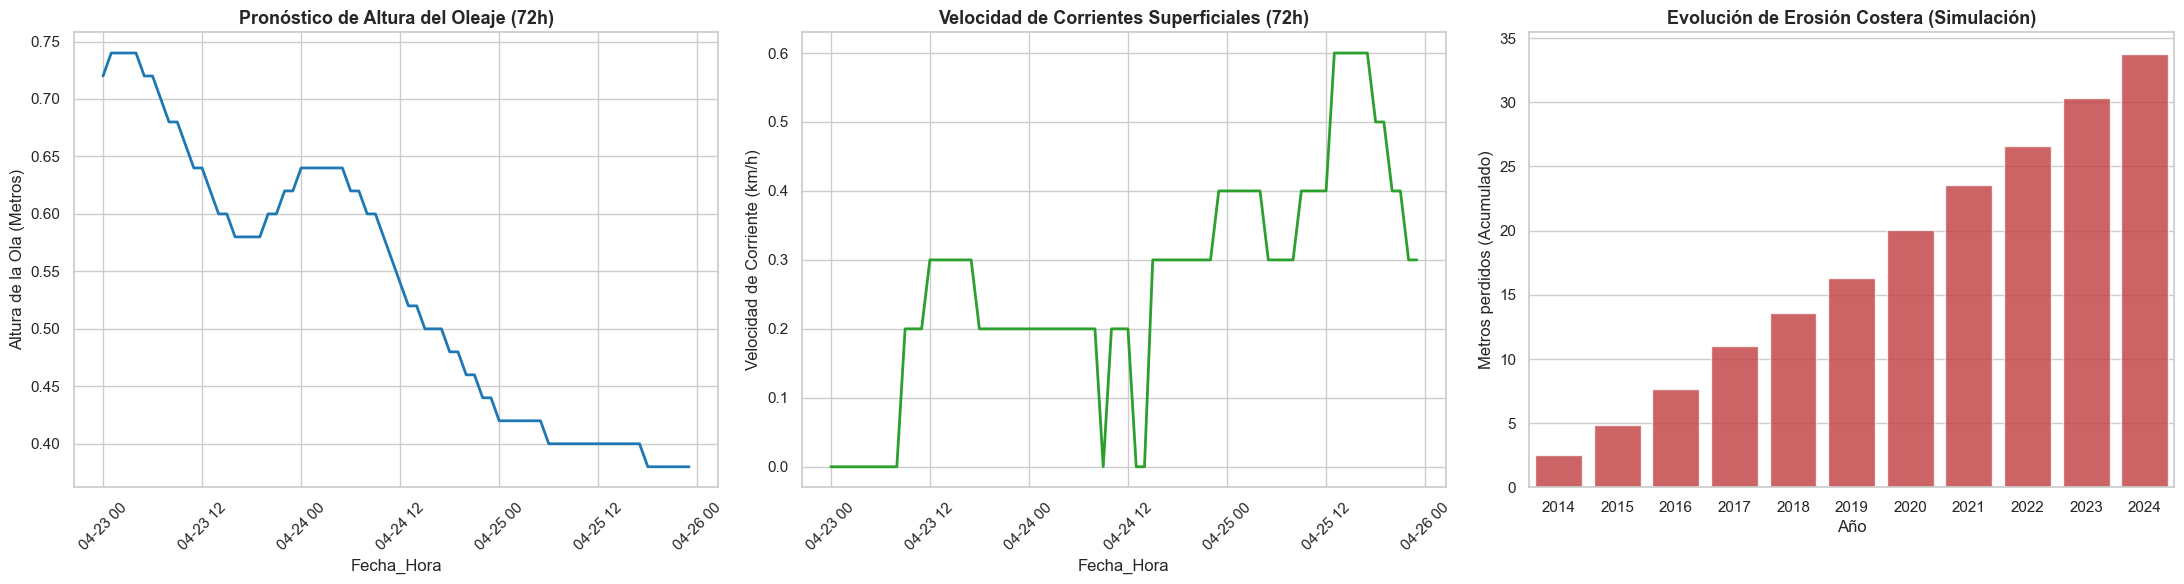

In [7]:
# 4. Visualización Completa (Oleaje, Corrientes y Erosión)
fig, ax = plt.subplots(1, 3, figsize=(22, 6))

# Gráfico 1: Altura de Olas
sns.lineplot(x='Fecha_Hora', y='Altura_Ola_m', data=df_ocean.head(72), ax=ax[0], color='#1f77b4', linewidth=2)
ax[0].set_title('Pronóstico de Altura del Oleaje (72h)', fontsize=13, fontweight='bold')
ax[0].set_ylabel('Altura de la Ola (Metros)')
ax[0].tick_params(axis='x', rotation=45)

# Gráfico 2: Velocidad de Corrientes de Agua 
sns.lineplot(x='Fecha_Hora', y='Velocidad_Corriente_kmh', data=df_ocean.head(72), ax=ax[1], color='#2ca02c', linewidth=2)
ax[1].set_title('Velocidad de Corrientes Superficiales (72h)', fontsize=13, fontweight='bold')
ax[1].set_ylabel('Velocidad de Corriente (km/h)')
ax[1].tick_params(axis='x', rotation=45)

# Gráfico 3: Erosión
sns.barplot(x='Año', y='Perdida_Acumulada_m', data=df_erosion, ax=ax[2], color='#d62728', alpha=0.8)
ax[2].set_title('Evolución de Erosión Costera (Simulación)', fontsize=13, fontweight='bold')
ax[2].set_ylabel('Metros perdidos (Acumulado)')

plt.tight_layout()

# NUEVA LÍNEA: Guardar la gráfica como imagen de alta resolución (300 dpi)
plt.savefig('graficas_palomino.png', dpi=300, bbox_inches='tight')

plt.show()